# Contact Matrix Exploration

This notebook keeps matrix setup lightweight by using:

- small named presets for within-group transmission
- sparse bridge overrides only where needed
- a helper that emits the full matrix in engine order

For interpretability, disease parameters are shared across groups by default.
You can toggle asymmetric disease parameters explicitly in the setup cell.

## Pedagogical Hypothesis Scaffold

This notebook is a pedagogical tool, not a direct inference engine from raw outbreak data.

Curriculum often works in reverse: choose a model behavior worth understanding, then show what assumptions generate it.
That is useful for learning, as long as assumptions and falsifiers are explicit.

### Hypothesis Being Illustrated
- Population structure and bridge coupling can produce outcomes that are hard to intuit from aggregate data alone.

### Assumptions in This Run
- Contact matrix values are synthetic and chosen for interpretability.
- Disease parameters are explicitly set and displayed.
- This run demonstrates mechanism sensitivity, not event attribution.

### What Would Falsify This Specific Story
- The same qualitative pattern persists across broad parameter changes where this mechanism should stop dominating.
- Alternative structures explain the observations with fewer assumptions.

### Scope Reminder
- Use this notebook to build intuition and compare testable model stories.
- Do not treat any single run as proof of real-world mechanism.

In [1]:
from pathlib import Path
import sys
import importlib

# Make src/ importable whether cwd is repo root or notebooks/
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

# Optional hot-reload for iterative local development in a warm kernel.
# Set to True after editing package code, then re-run this cell.
ENABLE_RELOAD = False

import epi_structure.parameters as parameters_module
import epi_structure.model as model_module
import epi_structure.contact_matrix as contact_matrix_module

if ENABLE_RELOAD:
    parameters_module = importlib.reload(parameters_module)
    model_module = importlib.reload(model_module)
    contact_matrix_module = importlib.reload(contact_matrix_module)

DiseaseParameters = parameters_module.DiseaseParameters
PopulationParameters = parameters_module.PopulationParameters
SimulationParameters = parameters_module.SimulationParameters
StructuredEpidemicModel = model_module.StructuredEpidemicModel
preset_general_cluster = contact_matrix_module.preset_general_cluster
build_contact_matrix = contact_matrix_module.build_contact_matrix

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Matrix helper functions now live in the package API for reuse.
# Use a built-in preset, or build your own with build_contact_matrix(...).

names, contact_matrix = preset_general_cluster()

# Example custom override path (uncomment to use):
# names = ["general", "cluster"]
# contact_matrix = build_contact_matrix(
#     pop_names=names,
#     within={"general": 0.00004, "cluster": 0.0005},
#     bridges={
#         ("general", "cluster"): 0.00018,
#         ("cluster", "general"): 0.00001,
#     },
# )

In [3]:
names, contact_matrix = preset_general_cluster()

USE_ASYMMETRIC_DISEASE = False

shared_disease = DiseaseParameters(infectious_period=6.0, latent_period=2.5)
if USE_ASYMMETRIC_DISEASE:
    disease_by_group = {
        "general": DiseaseParameters(infectious_period=7.0, latent_period=3.0),
        "cluster": DiseaseParameters(infectious_period=5.0, latent_period=2.0),
    }
else:
    disease_by_group = {name: shared_disease for name in names}

populations = [
    PopulationParameters(
        name="general",
        size=10_000,
        beta=0.0,
        initial_infected=1,
        disease=disease_by_group["general"],
    ),
    PopulationParameters(
        name="cluster",
        size=500,
        beta=0.0,
        initial_infected=4,
        disease=disease_by_group["cluster"],
    ),
]

simulation = SimulationParameters(time_step=0.1, duration=60.0, output_stride=20)

print("Contact matrix (beta_ij):")
display(pd.DataFrame(contact_matrix, index=names, columns=names))

disease_summary = pd.DataFrame(
    [
        {
            "population": p.name,
            "infectious_period": p.disease.infectious_period,
            "latent_period": p.disease.latent_period,
            "waning_period": p.disease.waning_period,
        }
        for p in populations
    ]
).set_index("population")

print("Disease parameters by population:")
display(disease_summary)

Contact matrix (beta_ij):


,general,cluster
general,0.00004,0.00018
cluster,0.00001,0.00050


Disease parameters by population:


,infectious_period,latent_period,waning_period
population,,,
general,6.0,2.5,None
cluster,6.0,2.5,None


In [9]:
# Optional deep-dive diagnostic for peak timing intuition.
# Keep this off for normal narrative runs; enable only when investigating dynamics.
RUN_DIAGNOSTIC = False

if RUN_DIAGNOSTIC:
    rows = []
    infected0 = {p.name: p.initial_infected for p in populations}
    for i, p in enumerate(populations):
        pressure = sum(contact_matrix[i][j] * infected0[populations[j].name] for j in range(len(populations)))
        s0, e0, i0, r0 = p.initial_state
        infection_flow0 = s0 * pressure
        gamma = 1.0 / p.disease.infectious_period
        sigma = None if p.disease.latent_period is None else 1.0 / p.disease.latent_period

        if sigma is None:
            dE0 = 0.0
            dI0 = infection_flow0 - gamma * i0
        else:
            dE0 = infection_flow0 - sigma * e0
            dI0 = sigma * e0 - gamma * i0  # with E0=0 this starts negative

        rows.append({
            "population": p.name,
            "S0": s0,
            "I0": i0,
            "infection_pressure0": pressure,
            "infection_flow0": infection_flow0,
            "dE_dt_at_t0": dE0,
            "dI_dt_at_t0": dI0,
        })

    display(pd.DataFrame(rows).set_index("population"))
else:
    print("Diagnostic skipped (RUN_DIAGNOSTIC=False).")

Diagnostic skipped (RUN_DIAGNOSTIC=False).


In [4]:
model = StructuredEpidemicModel(
    populations=populations,
    contact_matrix=contact_matrix,
    simulation=simulation,
)
trajectory = model.simulate()

len(trajectory), trajectory[0].time, trajectory[-1].time

(31, 0.0, 60.0)

In [5]:
rows = []
for point in trajectory:
    row = {"time": point.time}
    for pop_name, pop_state in point.by_population.items():
        row[f"{pop_name}_infected"] = pop_state.infected
        row[f"{pop_name}_susceptible"] = pop_state.susceptible
    row["total_population"] = point.total_population
    rows.append(row)

results = pd.DataFrame(rows)

population_sizes = {p.name: p.size for p in populations}
for pop_name, pop_size in population_sizes.items():
    results[f"{pop_name}_infected_pct"] = 100.0 * results[f"{pop_name}_infected"] / pop_size

results.head()

,time,general_infected,general_susceptible,cluster_infected,cluster_susceptible,total_population,general_infected_pct,cluster_infected_pct
0,0.0,1.000000,9999.000000,4.000000,496.000000,10500.0,0.010000,0.800000
1,2.0,4.781033,9984.216924,3.375955,494.198898,10500.0,0.047810,0.675191
2,4.0,13.148022,9965.126775,3.464819,492.442085,10500.0,0.131480,0.692964
3,6.0,25.054949,9937.170188,3.828061,490.473315,10500.0,0.250549,0.765612
4,8.0,41.433752,9896.565320,4.362013,488.154966,10500.0,0.414338,0.872403


## Interpretation Note

Human intuition is notoriously weak for exponential dynamics, and this model has **coupled** growth terms across populations.

Use both panels together:
- **Absolute infected counts** for burden and operational impact
- **Percent infected** for within-group intensity

If the trajectories feel counterintuitive, that is expected; rely on the numeric summaries and diagnostics rather than eyeballing alone.

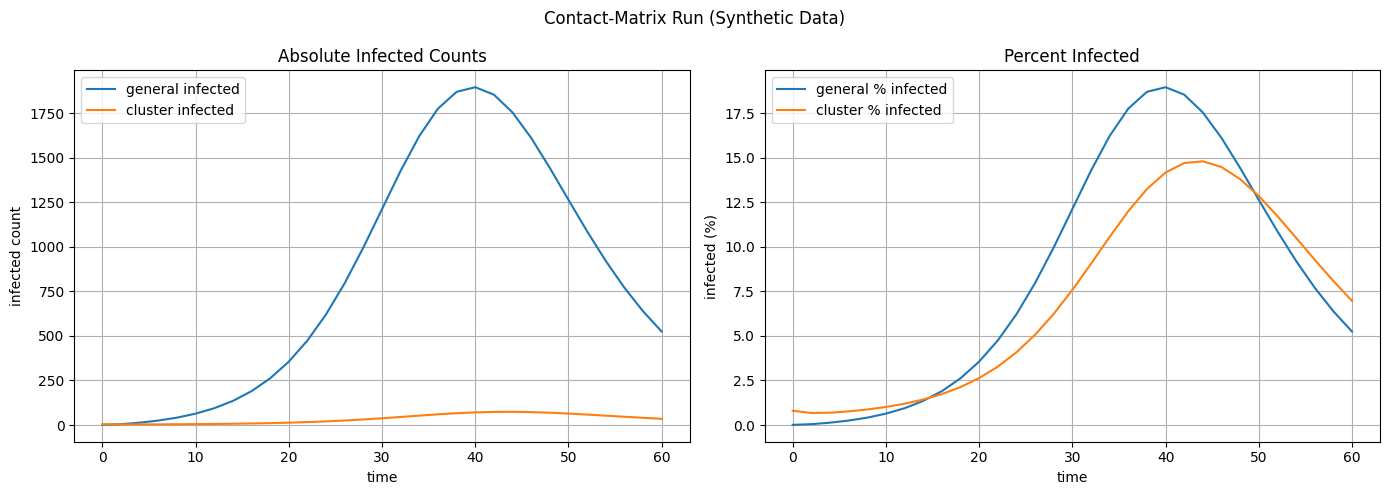

Population conservation check: 10500.0 -> 10500.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Absolute infected counts (policy-relevant burden)
axes[0].plot(results["time"], results["general_infected"], label="general infected")
axes[0].plot(results["time"], results["cluster_infected"], label="cluster infected")
axes[0].set_xlabel("time")
axes[0].set_ylabel("infected count")
axes[0].set_title("Absolute Infected Counts")
axes[0].grid(True)
axes[0].legend()

# Percent infected (shape/intensity comparison)
axes[1].plot(results["time"], results["general_infected_pct"], label="general % infected")
axes[1].plot(results["time"], results["cluster_infected_pct"], label="cluster % infected")
axes[1].set_xlabel("time")
axes[1].set_ylabel("infected (%)")
axes[1].set_title("Percent Infected")
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Contact-Matrix Run (Synthetic Data)")
plt.tight_layout()
plt.show()

print(
    "Population conservation check:",
    round(results["total_population"].iloc[0], 6),
    "->",
    round(results["total_population"].iloc[-1], 6),
)

In [7]:
assert len(results) > 0, "Expected non-empty output"
assert {"general_infected", "cluster_infected", "total_population"}.issubset(results.columns)
assert abs(results["total_population"].iloc[0] - results["total_population"].iloc[-1]) < 1e-6
assert results["cluster_infected"].max() >= results["cluster_infected"].iloc[0]
print("Lightweight assertions passed.")

Lightweight assertions passed.
